In [1]:
#Import the necessary modules
import cv2
import os
import matplotlib.pyplot as plt

In [2]:
def basic_image_manipulation(image_path):
    # Try loading the image using try except block for better image handling
    try:
        img = cv2.imread(image_path)
        if img is None:
            raise FileNotFoundError(f"Could not load image from path: {image_path}")
    except Exception as e:
        print(f" Error: {e}")
        return
    
    # Create output directory that will save the images
    os.makedirs('output_task1', exist_ok=True)
    
    # 1. Convert to grayscale as edge detection works on intensity values
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    cv2.imwrite('output_task1/grayscale.jpg', gray)
    
    # 2. Apply Gaussian Blur on grayscale as smoothing helps to find true edges
    blurred = cv2.GaussianBlur(gray, (15, 15), 0)
    cv2.imwrite('output_task1/blurred.jpg', blurred)
    
    # 3. Fianlly, Detect edges using Canny on blurred image
    edges = cv2.Canny(blurred, 34, 54)
    cv2.imwrite('output_task1/edges.jpg', edges)
    
    print("Task 1 is completed. Output images are saved in 'output_task1' folder.")

    # Also, Display all images using matplotlib to visualize and test it within
    plt.figure(figsize=(12, 4))
    
    # Original Image (converted to RGB for display)
    plt.subplot(1, 4, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis('off')
    
    # Plotting Grayscale Image
    plt.subplot(1, 4, 2)
    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale Image")
    plt.axis('off')
    
    #Plotting after Blurred Image in grayscale
    plt.subplot(1, 4, 3)
    plt.imshow(blurred, cmap='gray')
    plt.title("Blurred Image")
    plt.axis('off')
    
    # Plotting after applying Canny Edges in grayscale and blurred image
    plt.subplot(1, 4, 4)
    plt.imshow(edges, cmap='gray')
    plt.title("Canny Edges")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Optional: Open Canny tuning window to track the max and min thereshold for image edge detection
    open_canny_tuner(blurred)


In [3]:
# Interactive Threshold Tuner using Trackbars for correct edge findings
def open_canny_tuner(blurred_img):
    def nothing(x): pass

    cv2.namedWindow("Canny Tuner")
    cv2.createTrackbar("Min", "Canny Tuner", 50, 500, nothing)
    cv2.createTrackbar("Max", "Canny Tuner", 150, 500, nothing)

    while True:
        # Check if window still exists
        try:
            min_val = cv2.getTrackbarPos("Min", "Canny Tuner")
            max_val = cv2.getTrackbarPos("Max", "Canny Tuner")
            edges = cv2.Canny(blurred_img, min_val, max_val)
            cv2.imshow("Canny Tuner", edges)
        except:
            # Window was closed
            break
            
        key = cv2.waitKey(1)
        if key == 27 or cv2.getWindowProperty("Canny Tuner", cv2.WND_PROP_VISIBLE) < 1:  # Esc or window closed
            break

    cv2.destroyAllWindows()

Task 1 is completed. Output images are saved in 'output_task1' folder.


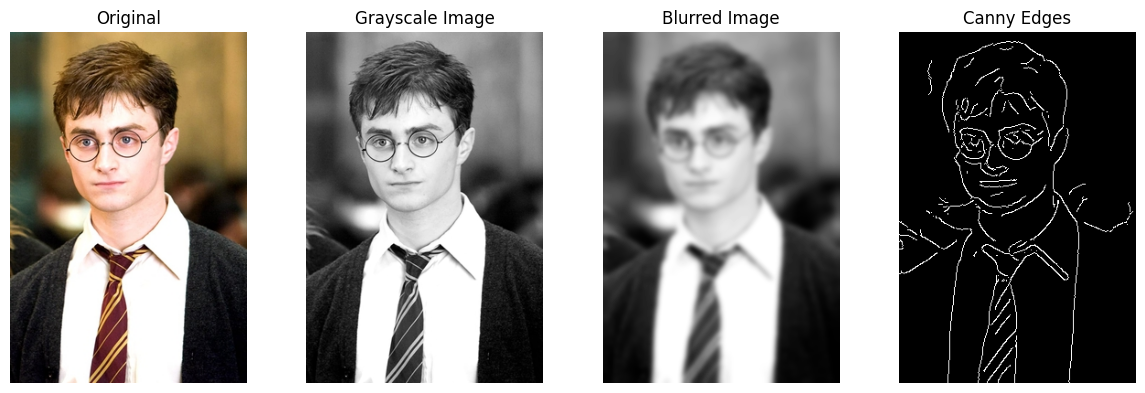

In [4]:
# call the function with the input image you want to place
basic_image_manipulation('Potter.jpg')